<a href="https://colab.research.google.com/github/dhrisit07-cloud/heart-disease-predictor/blob/main/heart_disease_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing necessary libraries

In [ ]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import joblib # For model persistence
import shap # For model explainability

import warnings
warnings.filterwarnings("ignore")


shap instrallation

In [ ]:
!pip install shap

Dataset selection and loading

In [ ]:
# 2. Dataset Selection and Loading
dataset_filename = 'heart.csv'

try:
    df = pd.read_csv(dataset_filename)
    print(f"Dataset '{dataset_filename}' loaded successfully.")
except FileNotFoundError:
    print(f"Error: '{dataset_filename}' not found.")
    print("Please make sure the file is in the same directory as the script.")
    exit()
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please check the file format or name.")
    exit()


Dataset 'heart.csv' loaded successfully.


Data exploration and preprocessing


--- Data Exploration and Preprocessing ---
Shape of the dataset: (918, 12)

First 5 rows of the dataset:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Basic statistics for numerical columns:
              Age   RestingBP  Cholesterol   FastingBS      

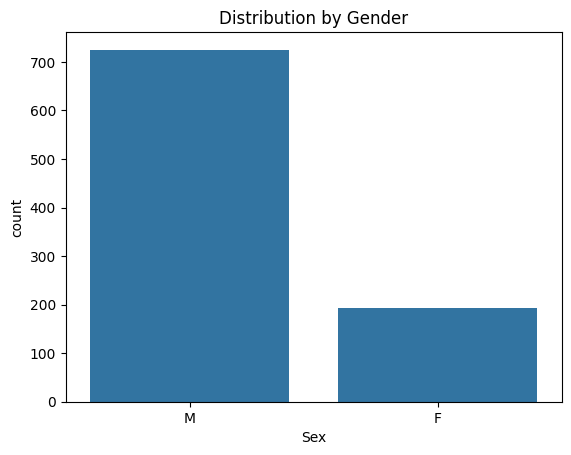

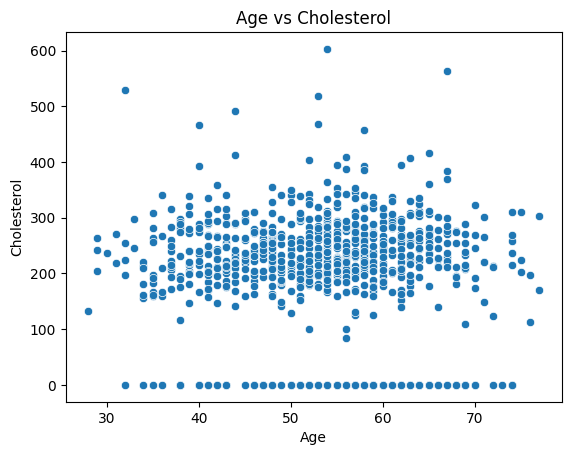

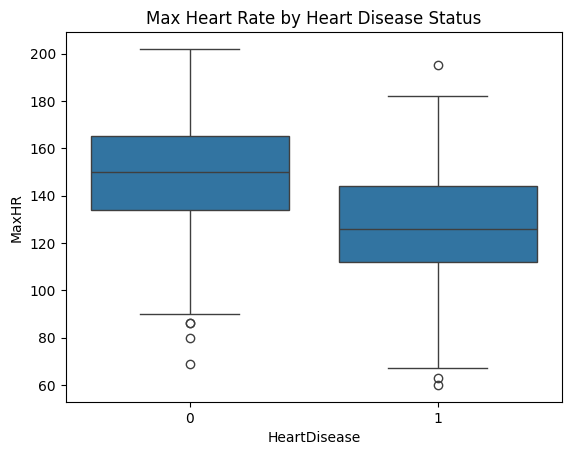


Shape of the dataset after dropping missing values: (918, 12)

Target variable distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64


In [ ]:
# 3. Data Exploration and Preprocessing (Tailored for heart.csv)
print("\n--- Data Exploration and Preprocessing ---")
print(f"Shape of the dataset: {df.shape}")
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Identify categorical and numerical columns based on heart.csv
categorical_cols = [
    'Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'
]
numerical_cols = [
    'Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'
]

#Basic Statistics
print("\nBasic statistics for numerical columns:")
print(df[numerical_cols].describe())
print("\nMedian values for numerical columns:")
print(df[numerical_cols].median())

# Distribution of patients by Gender
sns.countplot(x='Sex', data=df)
plt.title('Distribution by Gender')
plt.show()

# Relationship between Age and Cholesterol
sns.scatterplot(x='Age', y='Cholesterol', data=df)
plt.title('Age vs Cholesterol')
plt.show()

# Maximum Heart Rate vs Heart Disease presence
sns.boxplot(x='HeartDisease', y='MaxHR', data=df)
plt.title('Max Heart Rate by Heart Disease Status')
plt.show()

# The target column 'HeartDisease' is already in a 0/1 format, so no mapping is needed.
# We will drop rows with any missing values, although this dataset is clean.
df.dropna(inplace=True)
print(f"\nShape of the dataset after dropping missing values: {df.shape}")

# Check the distribution of the target variable
print("\nTarget variable distribution:")
print(df['HeartDisease'].value_counts())


# We will use one-hot encoding for all categorical columns.
# We need to correctly handle the column names to match the interactive prediction section later.
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

Splitting of data into features and target

In [ ]:
# 4. Split data into features (X) and target (y)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Correctly handle columns with special characters and replace spaces
X.columns = X.columns.str.replace(' ', '_')
X.columns = X.columns.str.replace('(', '')
X.columns = X.columns.str.replace(')', '')
X.columns = X.columns.str.replace('/', '_')

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")



Training data shape: (734, 15)
Testing data shape: (184, 15)


Feature scaling and Class imbalance Handling

In [ ]:
# 5. Feature Scaling and Class Imbalance Handling
# Scaling features is crucial for models that are sensitive to magnitude, like SVM and Logistic Regression.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Calculate statistics for outlier detection in user input
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
stats = X_train_df.agg(['mean', 'std']).T

# Check for class imbalance and apply SMOTE if needed
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print("\nClass imbalance detected. Applying SMOTE to the training data.")
print("Original training set shape:", X_train_scaled.shape, y_train.shape)
print("Resampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)
X_train_final = X_train_resampled
y_train_final = y_train_resampled

# --- Helper function for visualization ---
def plot_confusion_matrix(y_true, y_pred, model_name):
    """Plots a confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Heart Disease', 'Heart Disease'],
                yticklabels=['No Heart Disease', 'Heart Disease'])
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()



Class imbalance detected. Applying SMOTE to the training data.
Original training set shape: (734, 15) (734,)
Resampled training set shape: (802, 15) (802,)


Model training and evaluation


--- Model Training and Evaluation ---

--- Logistic Regression ---
Accuracy: 0.8587
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        77
           1       0.91      0.84      0.87       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



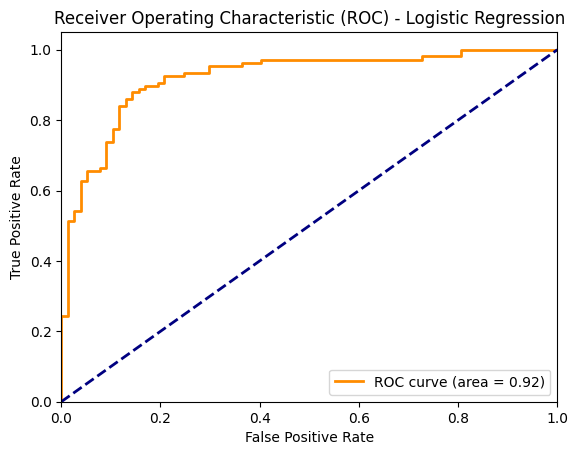


--- Random Forest Classifier ---
Accuracy: 0.8696
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85        77
           1       0.90      0.88      0.89       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184


--- XGBoost Classifier with Hyperparameter Tuning ---
Best parameters found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Accuracy: 0.8533
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83        77
           1       0.89      0.85      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184



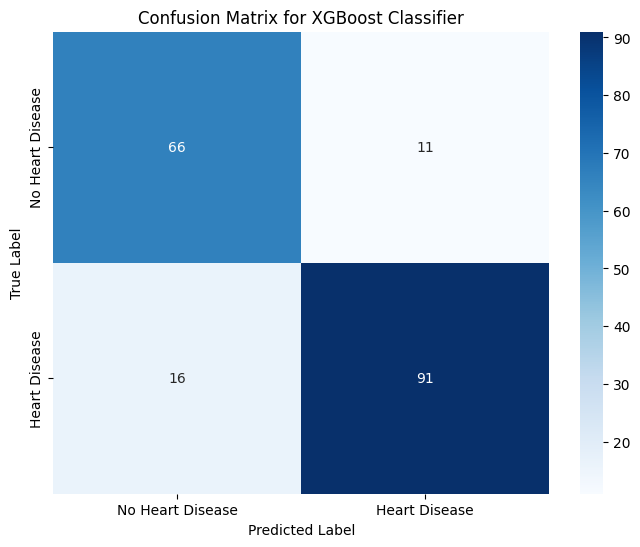


--- Decision Tree Classifier ---
Accuracy: 0.8098
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78        77
           1       0.86      0.80      0.83       107

    accuracy                           0.81       184
   macro avg       0.80      0.81      0.81       184
weighted avg       0.81      0.81      0.81       184



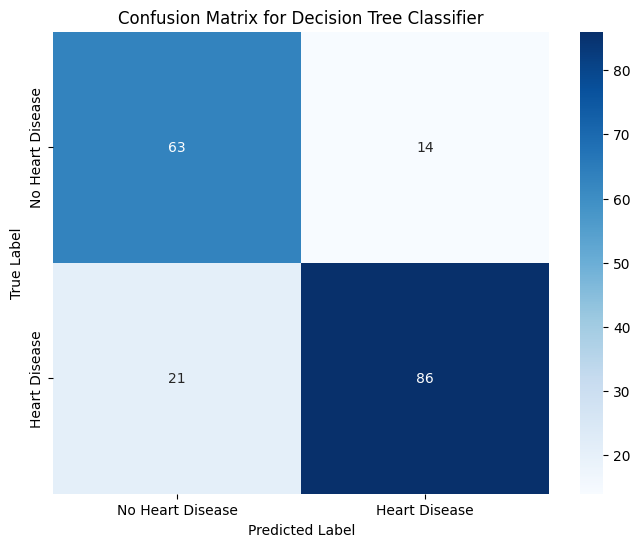


--- Support Vector Machine ---
Accuracy: 0.8750
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85        77
           1       0.90      0.88      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



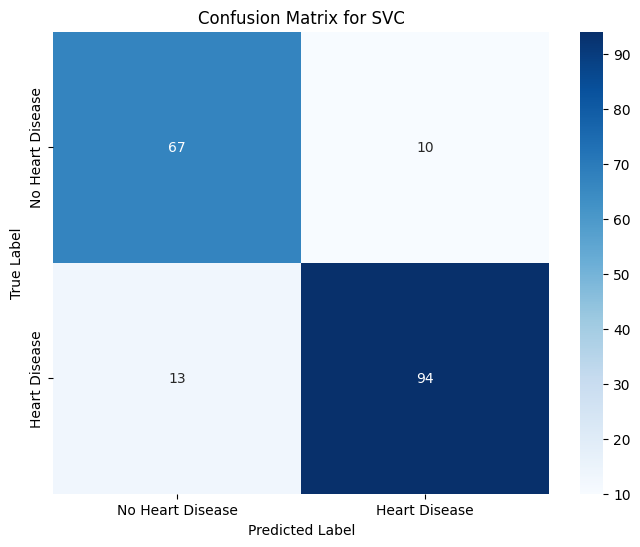


--- Model Explainability (SHAP) ---

SHAP Summary Plot:


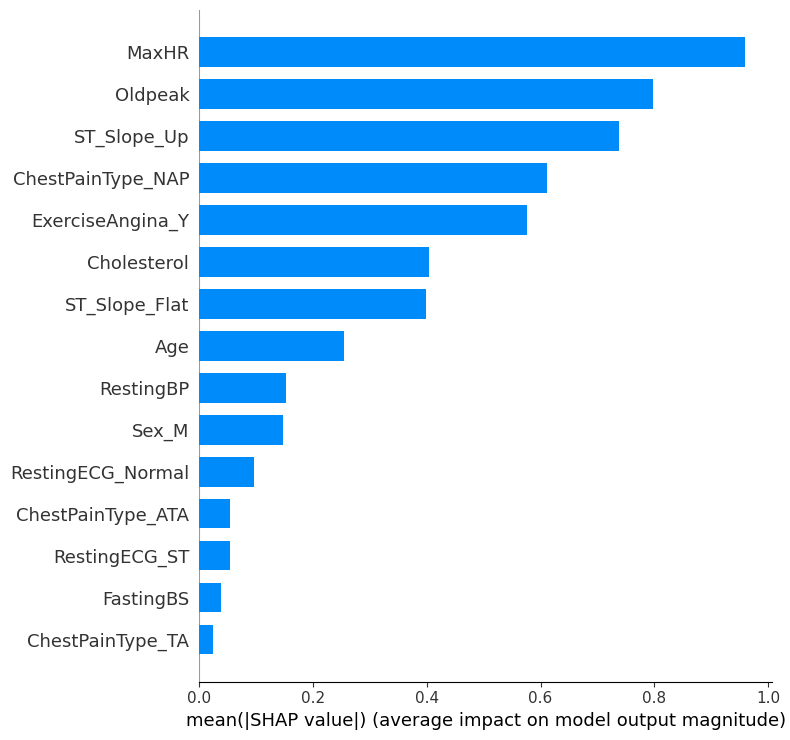


--- Model Persistence ---
Trained model saved to 'best_xgb_model.joblib'

--- Making a new prediction interactively ---
Please enter the following data when prompted:
Note: The model is not a clinical tool and does not provide a time horizon for risk.
Trained model loaded from 'best_xgb_model.joblib'


In [ ]:
# 6. Model Training and Evaluation
print("\n--- Model Training and Evaluation ---")

# --- Model 1: Logistic Regression ---
print("\n--- Logistic Regression ---")
log_reg = LogisticRegression(solver='liblinear', random_state=42)
log_reg.fit(X_train_final, y_train_final)
y_pred_log_reg = log_reg.predict(X_test_scaled)
y_prob_log_reg = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_log_reg)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

# --- Model 2: Random Forest Classifier ---
print("\n--- Random Forest Classifier ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_final, y_train_final)
y_pred_rf = rf_model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# --- Model 3: XGBoost Classifier with Hyperparameter Tuning ---
print("\n--- XGBoost Classifier with Hyperparameter Tuning ---")
param_grid_xgb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb, refit=True, verbose=0, cv=3)
grid_search_xgb.fit(X_train_final, y_train_final)
print(f"Best parameters found: {grid_search_xgb.best_params_}")
best_xgb_model = grid_search_xgb.best_estimator_

y_pred_xgb = best_xgb_model.predict(X_test_scaled)
y_prob_xgb = best_xgb_model.predict_proba(X_test_scaled)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Plot Confusion Matrix for the best model (XGBoost)
plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost Classifier")

# --- Model 4: Decision Tree Classifier ---
print("\n--- Decision Tree Classifier ---")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_final, y_train_final)
y_pred_dt = dt_model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))
plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree Classifier")

# --- Model 5: Support Vector Machine (SVC) ---
# Using probability=True for predict_proba which is needed for ROC curve, but it makes training slower
print("\n--- Support Vector Machine ---")
svc_model = SVC(probability=True, random_state=42)
svc_model.fit(X_train_final, y_train_final)
y_pred_svc = svc_model.predict(X_test_scaled)
y_prob_svc = svc_model.predict_proba(X_test_scaled)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svc))
plot_confusion_matrix(y_test, y_pred_svc, "SVC")

# Plot Confusion Matrix for the best model (XGBoost)
#plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost Classifier")

# --- Model Explainability (SHAP) ---
print("\n--- Model Explainability (SHAP) ---")
try:
    explainer = shap.TreeExplainer(best_xgb_model)
    shap_values = explainer.shap_values(X_test)

    print("\nSHAP Summary Plot:")
    shap.summary_plot(shap_values, X_test, plot_type="bar")
    plt.show()

except Exception as e:
    print(f"An error occurred during SHAP explanation: {e}")

# --- Model Persistence ---
model_filename = "best_xgb_model.joblib"
print("\n--- Model Persistence ---")
try:
    joblib.dump(best_xgb_model, model_filename)
    print(f"Trained model saved to '{model_filename}'")
except Exception as e:
    print(f"Error saving model: {e}")

# --- Interactive New Prediction ---
print("\n--- Making a new prediction interactively ---")
print("Please enter the following data when prompted:")
print("Note: The model is not a clinical tool and does not provide a time horizon for risk.")

# Load the trained model if it exists
if os.path.exists(model_filename):
    try:
        best_model = joblib.load(model_filename)
        print(f"Trained model loaded from '{model_filename}'")
    except Exception as e:
        print(f"Error loading model: {e}")
        best_model = best_xgb_model # Fallback to the model trained in this session
else:
    best_model = best_xgb_model

def get_valid_input(prompt, type_func, valid_options=None):
    """Function to get and validate user input."""
    while True:
        try:
            user_input = input(prompt).strip()
            if valid_options and user_input not in valid_options:
                print(f"Error: Invalid input. Please choose from {valid_options}.")
            else:
                return user_input
        except ValueError:
            print(f"Error: Invalid input. Please try again.")

def check_outlier(feature, value):
    """Checks if a numerical value is a potential outlier based on training data stats."""
    feature_name = feature.replace(' ', '_')
    if feature_name in stats.index:
        mean = stats.loc[feature_name, 'mean']
        std = stats.loc[feature_name, 'std']
        if abs(value - mean) > 2 * std:
            print(f"Warning: The value for '{feature}' seems unusually high or low compared to the training data. This might affect the prediction.")
    else:
        print(f"Warning: Could not find statistics for '{feature}'.")


Heart Disease prediction model

In [ ]:
# Dictionary to map categorical strings to their numeric representation
# based on the columns created by pd.get_dummies
categorical_mappings = {
    'Sex': {'M': 'Sex_M', 'F': None},
    'ChestPainType': {'ATA': 'ChestPainType_ATA', 'NAP': 'ChestPainType_NAP', 'ASY': 'ChestPainType_ASY', 'TA': 'ChestPainType_TA', None: None},
    'RestingECG': {'Normal': 'RestingECG_Normal', 'ST': 'RestingECG_ST', 'LVH': 'RestingECG_LVH', None: None},
    'ExerciseAngina': {'Y': 'ExerciseAngina_Y', 'N': None},
    'ST_Slope': {'Up': 'ST_Slope_Up', 'Flat': 'ST_Slope_Flat', 'Down': 'ST_Slope_Down', None: None}
}

new_data_dict = {}

# Prompt for numerical inputs and check for outliers
for col in numerical_cols:
    value = float(input(f"{col}: ").strip())
    check_outlier(col, value)
    new_data_dict[col] = value

# Prompt for categorical inputs and map to one-hot encoded columns
for col, mapping in categorical_mappings.items():
    # Filter out None from the keys to avoid the TypeError
    prompt_options = [key for key in mapping.keys() if key is not None]
    user_choice = get_valid_input(f"{col} ({'/'.join(prompt_options)}): ", str, prompt_options)
    one_hot_col = mapping[user_choice]
    if one_hot_col:
        new_data_dict[one_hot_col] = 1

# Create the new DataFrame
new_df = pd.DataFrame([new_data_dict])
new_df.columns = new_df.columns.str.replace(' ', '_')

# Re-align columns to match the training data
new_data_aligned = new_df.reindex(columns=X.columns, fill_value=0)

# Scale the numerical features using the *same scaler* from the training phase
new_data_scaled = scaler.transform(new_data_aligned)

# Get the binary prediction and the probability score
prediction = best_model.predict(new_data_scaled)
probability = best_model.predict_proba(new_data_scaled)[:, 1]

print("\n--- Prediction Results ---")
print(f"Prediction for your data: {'Heart Disease' if prediction[0] == 1 else 'No Heart Disease'}")
print(f"Probability of having heart disease: {probability[0]:.2f}")


Age: 19
RestingBP: 100
Cholesterol: 300
FastingBS: 150
MaxHR: 110
Oldpeak: 0
Sex (M/F): F
ChestPainType (ATA/NAP/ASY/TA): NAP
RestingECG (Normal/ST/LVH): Normal
ExerciseAngina (Y/N): N
ST_Slope (Up/Flat/Down): Flat

--- Prediction Results ---
Prediction for your data: Heart Disease
Probability of having heart disease: 0.50
